In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Matplotlib is building the font cache; this may take a moment.


In [2]:
from pathlib import Path

In [3]:
train_path = Path("../data/raw/train.csv")
test_path = Path("../data/raw/test.csv")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (120000, 3)
Test shape: (7600, 3)


In [4]:
print("Train columns:")
print(train_df.columns.tolist())

print("\nTest columns:")
print(test_df.columns.tolist())

Train columns:
['Class Index', 'Title', 'Description']

Test columns:
['Class Index', 'Title', 'Description']


In [5]:
train_df.head()

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [6]:
test_df.head()

,Class Index,Title,Description
0,3,Fears for T N pension after talks,Unions representing workers at Turner Newall...
1,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o..."
2,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...
3,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...
4,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...


In [8]:
train_df.columns = ["label", "title", "description"]
test_df.columns = ["label", "title", "description"]

In [9]:
train_df.head()

,label,title,description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [10]:
label_map = {
    1: "World",
    2: "Sports",
    3: "Business",
    4: "Sci/Tech"
}

train_df["category"] = train_df["label"].map(label_map)
test_df["category"] = test_df["label"].map(label_map)

In [11]:
train_df[["label", "category"]].head(10)

,label,category
0,3,Business
1,3,Business
2,3,Business
3,3,Business
4,3,Business
5,3,Business
6,3,Business
7,3,Business
8,3,Business
9,3,Business


In [12]:
test_df[["label", "category"]].head(10)

,label,category
0,3,Business
1,4,Sci/Tech
2,4,Sci/Tech
3,4,Sci/Tech
4,4,Sci/Tech
5,4,Sci/Tech
6,4,Sci/Tech
7,4,Sci/Tech
8,4,Sci/Tech
9,4,Sci/Tech


In [13]:
#check missing values 
print(train_df.isnull().sum())

label          0
title          0
description    0
category       0
dtype: int64


In [14]:
print(test_df.isnull().sum())

label          0
title          0
description    0
category       0
dtype: int64


In [15]:
#for duplicated rows
print("Train duplicates:", train_df.duplicated().sum())
print("Test duplicates:", test_df.duplicated().sum())

Train duplicates: 0
Test duplicates: 0


In [16]:
#Category distribution
print(train_df["category"].value_counts())

category
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64


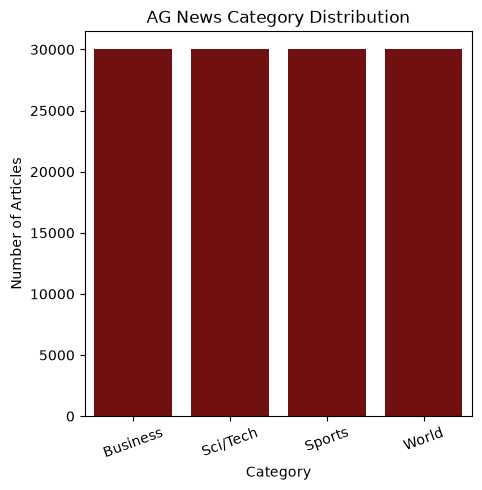

In [21]:
plt.figure(figsize=(5, 5))

sns.countplot(
    data=train_df,
    x="category",color="maroon"
)

plt.title("AG News Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Articles")
plt.xticks(rotation=20)

plt.show()

In [22]:
#Create the actual text  For our NLP model, we'll combine:text+description
train_df["text"] = (
    train_df["title"].fillna("") + " " +
    train_df["description"].fillna("")
)

test_df["text"] = (
    test_df["title"].fillna("") + " " +
    test_df["description"].fillna("")
)

In [23]:
train_df[["title", "description", "text"]].head()

,title,description,text
0,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",Wall St. Bears Claw Back Into the Black (Reute...
1,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,Carlyle Looks Toward Commercial Aerospace (Reu...
2,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,Oil and Economy Cloud Stocks' Outlook (Reuters...
3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,Iraq Halts Oil Exports from Main Southern Pipe...
4,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...","Oil prices soar to all-time record, posing new..."


In [24]:
train_df[["text"]].head()

,text
0,Wall St. Bears Claw Back Into the Black (Reute...
1,Carlyle Looks Toward Commercial Aerospace (Reu...
2,Oil and Economy Cloud Stocks' Outlook (Reuters...
3,Iraq Halts Oil Exports from Main Southern Pipe...
4,"Oil prices soar to all-time record, posing new..."


In [25]:
#Text length analysis
train_df["word_count"] = train_df["text"].apply(
    lambda x: len(x.split())
)

In [26]:
train_df["word_count"]

0         21
1         36
2         36
3         36
4         37
          ..
119995    39
119996    55
119997    43
119998    64
119999    36
Name: word_count, Length: 120000, dtype: int64

In [27]:
train_df["word_count"].describe()

count    120000.000000
mean         37.844617
std          10.088702
min           4.000000
25%          32.000000
50%          37.000000
75%          43.000000
max         177.000000
Name: word_count, dtype: float64

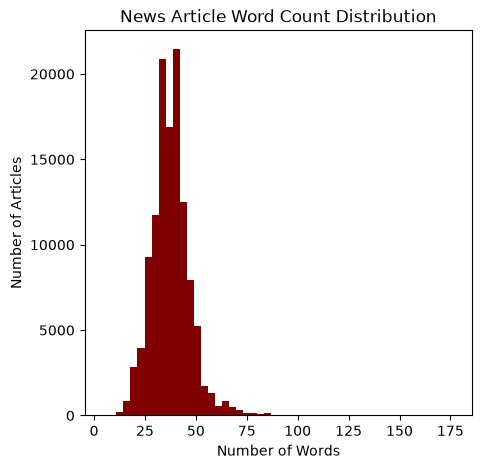

In [30]:
plt.figure(figsize=(5, 5))

plt.hist(
    train_df["word_count"],
    bins=50,color="maroon"
)

plt.title("News Article Word Count Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Articles")

plt.show()

In [31]:
#Most common words  -For EDA, we can first look at raw word frequency.
from collections import Counter

all_words = " ".join(
    train_df["text"].astype(str)
).lower().split()

word_counts = Counter(all_words)

word_counts.most_common(20)

[('the', 203224),
 ('to', 118911),
 ('a', 107276),
 ('of', 97857),
 ('in', 95250),
 ('and', 68617),
 ('on', 56304),
 ('for', 50070),
 ('-', 39095),
 ('#39;s', 31129),
 ('that', 27532),
 ('with', 26608),
 ('as', 25123),
 ('at', 24867),
 ('its', 21921),
 ('is', 21799),
 ('new', 21044),
 ('by', 20686),
 ('has', 18908),
 ('it', 18595)]

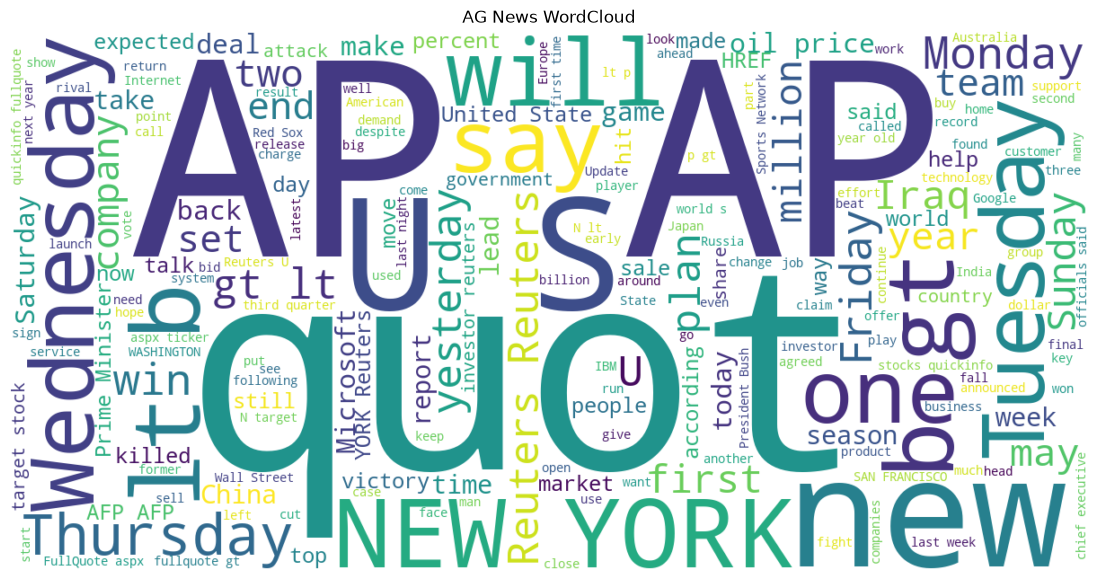

In [32]:
#wordcloud
from wordcloud import WordCloud

text = " ".join(train_df["text"].astype(str))

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("AG News WordCloud")

plt.show()

In [33]:
#Category-specific analysis
business_text = " ".join(
    train_df.loc[
        train_df["category"] == "Business",
        "text"
    ].astype(str)
)

print(business_text[:1000])

Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again. Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market. Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over the stock market next week during the depth of the\summer doldrums. Iraq Halts Oil Exports from Main Southern Pipeline (Reuters) Reuters - Authorities have halted oil export\flows from the main pipeline in southern Iraq after\intelligence showed a rebel militia could strike\infrastructure, an oil official said on Saturday. Oil prices soar to all-time record, posing new menace to US economy (AFP) AFP - Tearaway world oil

In [34]:

sports_text = " ".join(
    train_df.loc[
        train_df["category"] == "Sports",
        "text"
    ].astype(str)
)

print(sports_text[:1000])

Phelps, Thorpe Advance in 200 Freestyle (AP) AP - Michael Phelps took care of qualifying for the Olympic 200-meter freestyle semifinals Sunday, and then found out he had been added to the American team for the evening's 400 freestyle relay final. Phelps' rivals Ian Thorpe and Pieter van den Hoogenband and teammate Klete Keller were faster than the teenager in the 200 free preliminaries. Reds Knock Padres Out of Wild-Card Lead (AP) AP - Wily Mo Pena homered twice and drove in four runs, helping the Cincinnati Reds beat the San Diego Padres 11-5 on Saturday night. San Diego was knocked out of a share of the NL wild-card lead with the loss and Chicago's victory over Los Angeles earlier in the day. Dreaming done, NBA stars awaken to harsh Olympic reality (AFP) AFP - National Basketball Association players trying to win a fourth consecutive Olympic gold medal for the United States have gotten the wake-up call that the "Dream Team" days are done even if supporters have not. Indians Beat Twin

In [35]:
output_dir = Path("../data/interim")
output_dir.mkdir(parents=True, exist_ok=True)

train_df.to_csv(
    output_dir / "train_cleaned.csv",
    index=False
)

test_df.to_csv(
    output_dir / "test_cleaned.csv",
    index=False
)

print("Cleaned datasets saved successfully.")

Cleaned datasets saved successfully.
